# Data Exploration


In [44]:
import sys
import os

project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.insert(0, project_root)

In [45]:
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy import stats
from src.common import mpl_apply
import matplotlib.dates as mdates

In [46]:
df = pd.read_csv("../data/climate-daily-mount_pearl.csv")
df.head()

,x,y,STATION_NAME,CLIMATE_IDENTIFIER,ID,LOCAL_DATE,PROVINCE_CODE,LOCAL_YEAR,LOCAL_MONTH,LOCAL_DAY,...,SPEED_MAX_GUST,SPEED_MAX_GUST_FLAG,COOLING_DEGREE_DAYS,COOLING_DEGREE_DAYS_FLAG,HEATING_DEGREE_DAYS,HEATING_DEGREE_DAYS_FLAG,MIN_REL_HUMIDITY,MIN_REL_HUMIDITY_FLAG,MAX_REL_HUMIDITY,MAX_REL_HUMIDITY_FLAG
0,-52.783339,47.513356,ST JOHNS WEST CLIMATE,8403603,8403603.2010.8.24,2010-08-24 00:00:00,NL,2010,8,24,...,0.0,NaN,NaN,M,NaN,M,NaN,NaN,NaN,NaN
1,-52.783339,47.513356,ST JOHNS WEST CLIMATE,8403603,8403603.2010.8.25,2010-08-25 00:00:00,NL,2010,8,25,...,0.0,NaN,0.0,NaN,0.6,NaN,49.0,NaN,96.0,NaN
2,-52.783339,47.513356,ST JOHNS WEST CLIMATE,8403603,8403603.2010.8.26,2010-08-26 00:00:00,NL,2010,8,26,...,32.0,NaN,0.0,NaN,0.1,NaN,64.0,NaN,98.0,NaN
3,-52.783339,47.513356,ST JOHNS WEST CLIMATE,8403603,8403603.2010.8.27,2010-08-27 00:00:00,NL,2010,8,27,...,46.0,NaN,0.0,NaN,1.9,NaN,84.0,NaN,97.0,NaN
4,-52.783339,47.513356,ST JOHNS WEST CLIMATE,8403603,8403603.2010.8.28,2010-08-28 00:00:00,NL,2010,8,28,...,0.0,NaN,0.0,NaN,1.1,NaN,56.0,NaN,94.0,NaN


In [47]:
df = df.sort_values('LOCAL_DATE')

In [48]:
df.STATION_NAME.unique()

array(['ST JOHNS WEST CLIMATE'], dtype=object)

In [49]:
mpl_apply()

In [50]:
import pandas as pd
import matplotlib.pyplot as plt

# Create datetime from year/month/day
df['date'] = pd.to_datetime(df[['LOCAL_YEAR', 'LOCAL_MONTH', 'LOCAL_DAY']].rename(columns={
    'LOCAL_YEAR': 'year',
    'LOCAL_MONTH': 'month',
    'LOCAL_DAY': 'day'
}))

# Sort by date
df = df.sort_values('date')

In [51]:
df.columns

Index(['x', 'y', 'STATION_NAME', 'CLIMATE_IDENTIFIER', 'ID', 'LOCAL_DATE',
       'PROVINCE_CODE', 'LOCAL_YEAR', 'LOCAL_MONTH', 'LOCAL_DAY',
       'MEAN_TEMPERATURE', 'MEAN_TEMPERATURE_FLAG', 'MIN_TEMPERATURE',
       'MIN_TEMPERATURE_FLAG', 'MAX_TEMPERATURE', 'MAX_TEMPERATURE_FLAG',
       'TOTAL_PRECIPITATION', 'TOTAL_PRECIPITATION_FLAG', 'TOTAL_RAIN',
       'TOTAL_RAIN_FLAG', 'TOTAL_SNOW', 'TOTAL_SNOW_FLAG', 'SNOW_ON_GROUND',
       'SNOW_ON_GROUND_FLAG', 'DIRECTION_MAX_GUST', 'DIRECTION_MAX_GUST_FLAG',
       'SPEED_MAX_GUST', 'SPEED_MAX_GUST_FLAG', 'COOLING_DEGREE_DAYS',
       'COOLING_DEGREE_DAYS_FLAG', 'HEATING_DEGREE_DAYS',
       'HEATING_DEGREE_DAYS_FLAG', 'MIN_REL_HUMIDITY', 'MIN_REL_HUMIDITY_FLAG',
       'MAX_REL_HUMIDITY', 'MAX_REL_HUMIDITY_FLAG', 'date'],
      dtype='object')

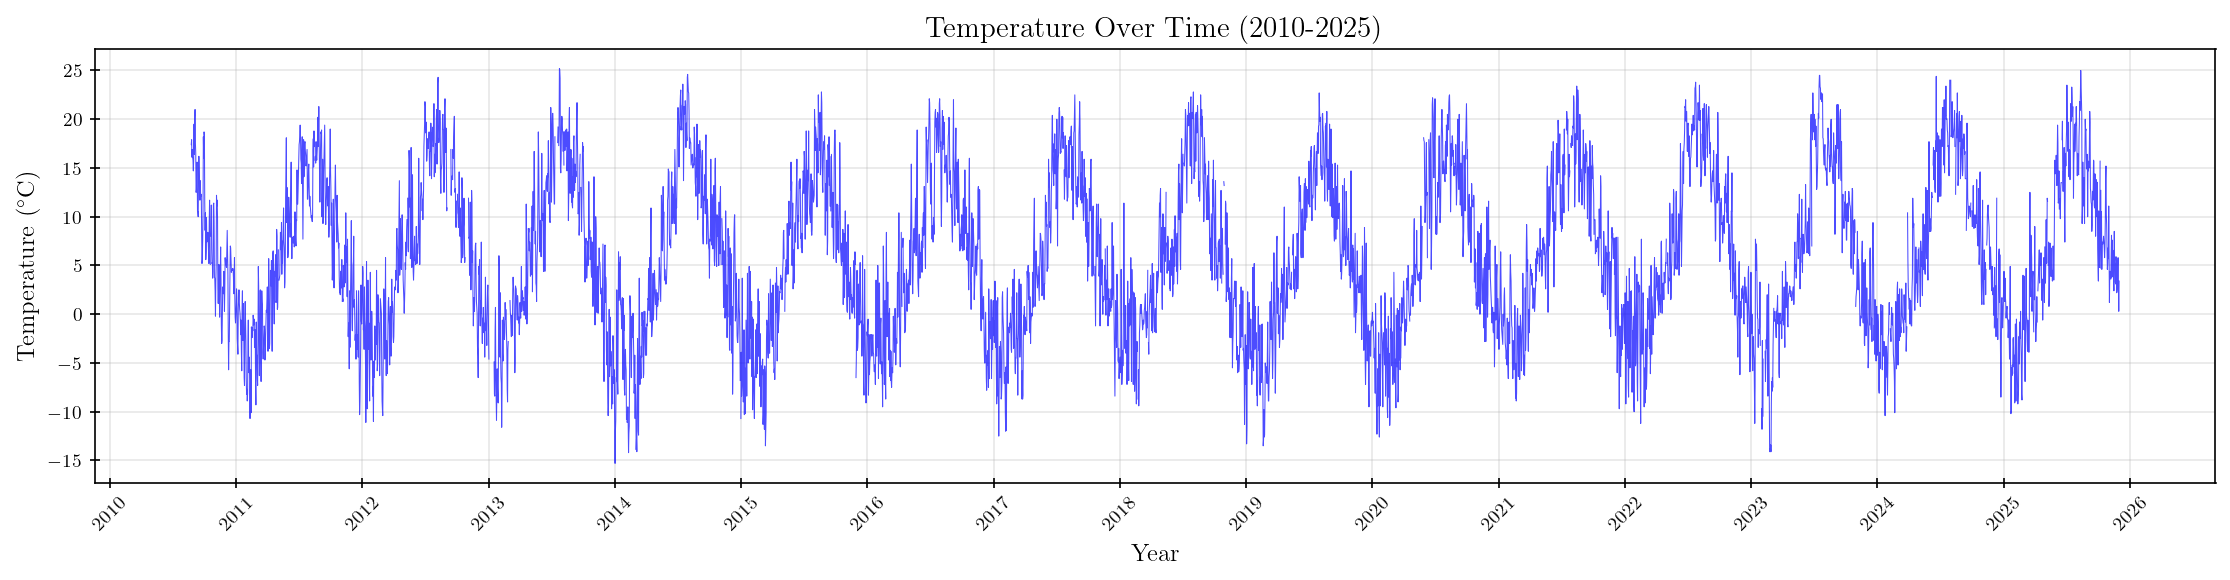

In [52]:
fig, ax = plt.subplots(figsize=(15, 4))
ax.plot(df['date'], df['MEAN_TEMPERATURE'],
        linewidth=0.5, alpha=0.7, color='blue')

ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.tick_params(axis='x', rotation=45)

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Temperature ($^{\\circ}$C)', fontsize=12)
ax.set_title('Temperature Over Time (2010-2025)', fontsize=14)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../plots/mean_temp_over_time.pdf")

## DTR Analysis

In [53]:
# Import DTR function
from src.dtr_calc import calculate_dtr

In [54]:
# Calculate dtr time series data
df["DTR"] = calculate_dtr(t_min=df["MIN_TEMPERATURE"],
                          t_max=df["MAX_TEMPERATURE"])

In [55]:
df.columns

Index(['x', 'y', 'STATION_NAME', 'CLIMATE_IDENTIFIER', 'ID', 'LOCAL_DATE',
       'PROVINCE_CODE', 'LOCAL_YEAR', 'LOCAL_MONTH', 'LOCAL_DAY',
       'MEAN_TEMPERATURE', 'MEAN_TEMPERATURE_FLAG', 'MIN_TEMPERATURE',
       'MIN_TEMPERATURE_FLAG', 'MAX_TEMPERATURE', 'MAX_TEMPERATURE_FLAG',
       'TOTAL_PRECIPITATION', 'TOTAL_PRECIPITATION_FLAG', 'TOTAL_RAIN',
       'TOTAL_RAIN_FLAG', 'TOTAL_SNOW', 'TOTAL_SNOW_FLAG', 'SNOW_ON_GROUND',
       'SNOW_ON_GROUND_FLAG', 'DIRECTION_MAX_GUST', 'DIRECTION_MAX_GUST_FLAG',
       'SPEED_MAX_GUST', 'SPEED_MAX_GUST_FLAG', 'COOLING_DEGREE_DAYS',
       'COOLING_DEGREE_DAYS_FLAG', 'HEATING_DEGREE_DAYS',
       'HEATING_DEGREE_DAYS_FLAG', 'MIN_REL_HUMIDITY', 'MIN_REL_HUMIDITY_FLAG',
       'MAX_REL_HUMIDITY', 'MAX_REL_HUMIDITY_FLAG', 'date', 'DTR'],
      dtype='object')

In [56]:
# Find invalid rows
invalid = df[df["MAX_TEMPERATURE"] < df["MIN_TEMPERATURE"]]
print(invalid[["date", "MIN_TEMPERATURE", "MAX_TEMPERATURE", "STATION_NAME"]])

Empty DataFrame
Columns: [date, MIN_TEMPERATURE, MAX_TEMPERATURE, STATION_NAME]
Index: []


In [57]:
print(f"Invalid samples: {len(invalid)}")
print(f"Total number of samples: {df.shape[0]}")

Invalid samples: 0
Total number of samples: 5568


#### All DTR samples

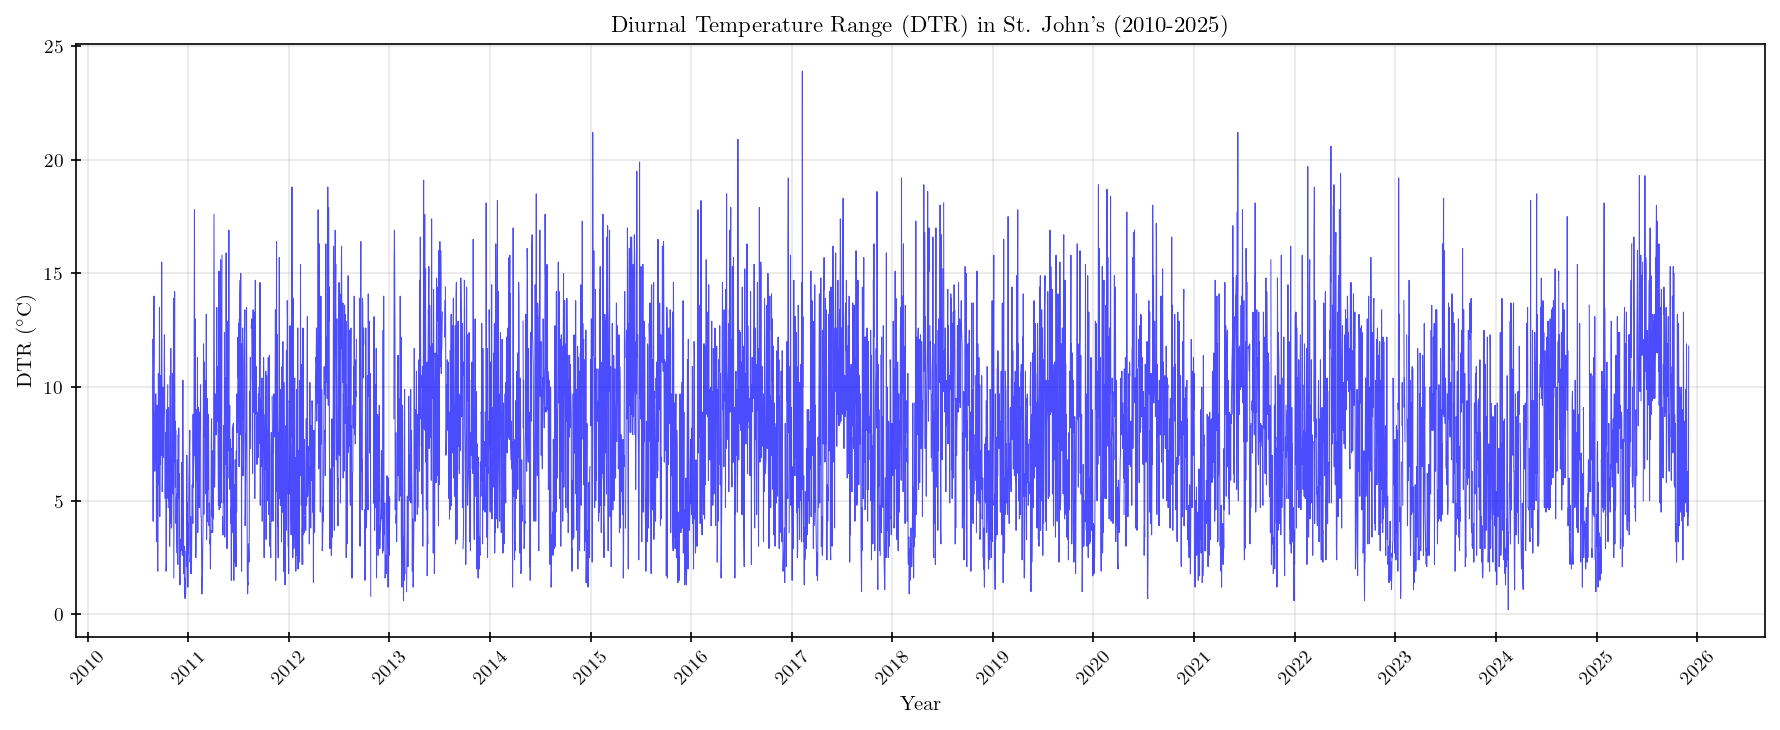

In [58]:
import matplotlib.dates as mdates

plt.figure(figsize=(12, 5))
plt.plot(df["date"], df["DTR"], color="blue", linewidth=0.5, alpha=0.7)
plt.title('Diurnal Temperature Range (DTR) in St. John\'s (2010-2025)')
plt.xlabel('Year')
plt.ylabel('DTR ($^{\\circ}$C)')

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../plots/dtr_over_time.pdf", dpi=300)
plt.show()

Plotting individual DTR values for each day, provides visual noise. I will try to see if I can find any trends/patterns in the yearly and/or monthly plot.

#### Yearly Mean DTR

In [59]:
# Calculate annual mean DTR
annual_dtr = df.groupby(df['date'].dt.year)['DTR'].mean()

# Fit linear trend
slope, intercept, r_value, p_value, std_err = stats.linregress(
    annual_dtr.index, annual_dtr.values
)

# Print statistics
print(f"Slope: {slope:.4f} °C/year")
print(f"Intercept: {intercept:.2f} °C")
print(f"p-value: {p_value:.3f}")
print(f"R²: {r_value**2:.3f}")
print(f"Significant at alpha=0.05? {'Yes' if p_value < 0.05 else 'No'}")

Slope: 0.0345 °C/year
Intercept: -61.74 °C
p-value: 0.337
R²: 0.066
Significant at alpha=0.05? No


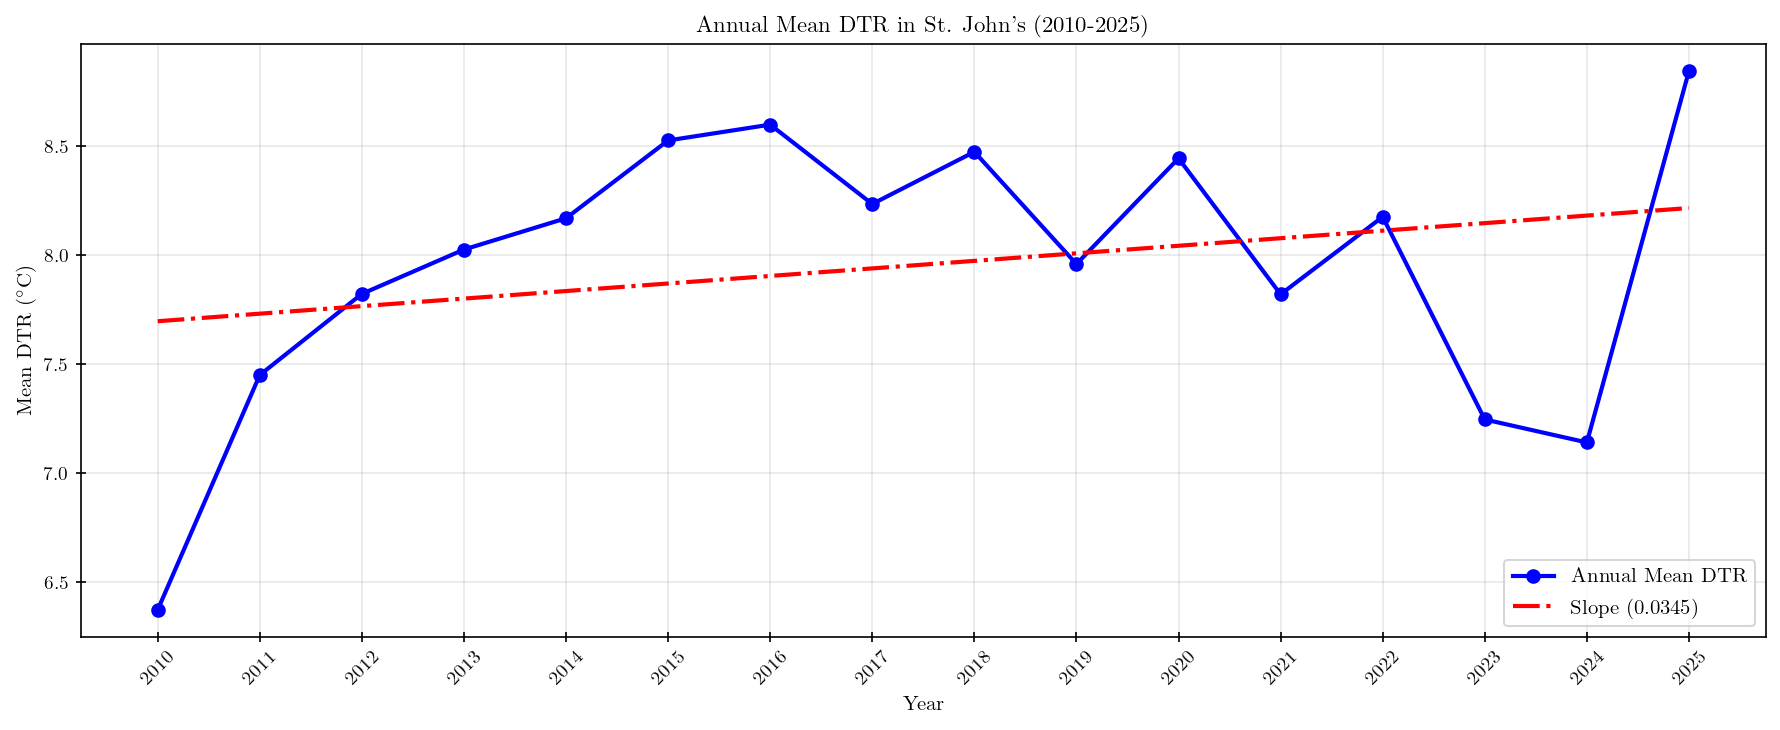

In [60]:

# Generate trendline
trend_line = slope * annual_dtr.index + intercept

plt.figure(figsize=(12, 5))
plt.plot(annual_dtr.index, annual_dtr.values, "-b",
         marker='o', linewidth=2, markersize=6, label='Annual Mean DTR')
plt.plot(annual_dtr.index, trend_line, 'r-.', linewidth=2,
         label=f'Slope (0.0345)')
plt.title('Annual Mean DTR in St. John\'s (2010-2025)')
plt.xlabel('Year')
plt.ylabel('Mean DTR ($^{\\circ}$C)')

plt.xticks(range(int(annual_dtr.index.min()), int(annual_dtr.index.max()) + 1, 1),
           rotation=45)

plt.grid(True, alpha=0.3)
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("../plots/annual_dtr_trend.pdf", dpi=300)
plt.show()

#### DTR Distribution by Month

<Figure size 1500x900 with 0 Axes>

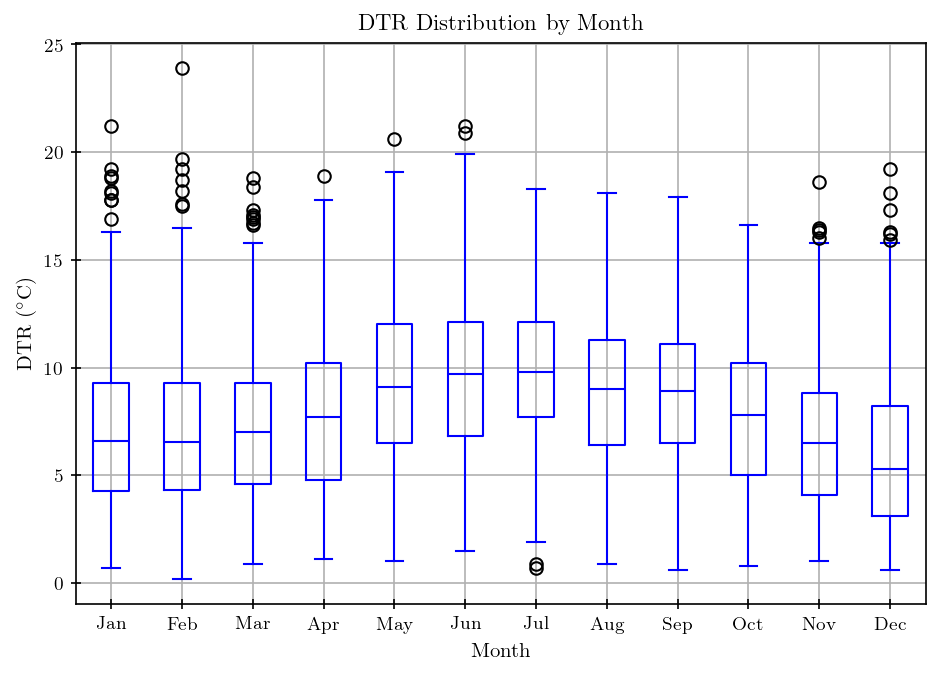

In [61]:
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

df['month'] = df['date'].dt.month
df['month_name'] = df['date'].dt.strftime('%b')

# Convert to categorical with chronological ordering
df['month_name'] = pd.Categorical(df['month_name'],
                                  categories=months,
                                  ordered=True)
plt.figure(figsize=(10, 6))
df.boxplot(column='DTR', color="blue", by='month_name')
plt.title('DTR Distribution by Month')
plt.suptitle('')
plt.xlabel('Month')
plt.ylabel('DTR ($^{\\circ}$C)')
plt.tight_layout()
plt.savefig("../plots/dtr_seasonal.pdf", dpi=300)

#### Mean DTR by Month

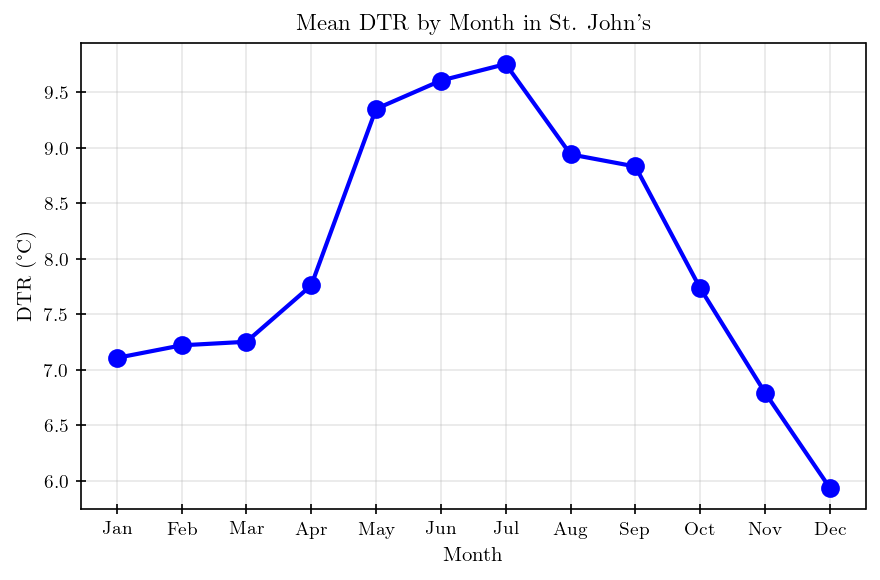

In [67]:
# Calculate mean DTR for each month across all years
monthly_dtr = df.groupby(df['date'].dt.month)['DTR'].mean()

# Plot
plt.figure(figsize=(6, 4))
plt.plot(monthly_dtr.index, monthly_dtr.values,
         'o-b', linewidth=2, markersize=8, label='Mean')

plt.title('Mean DTR by Month in St. John\'s')
plt.xlabel('Month')
plt.ylabel('DTR (°C)')

plt.xticks(range(1, 13), months)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../plots/dtr_by_month.pdf", dpi=300)

* Winter (Dec–Mar): Suppressed DTR (6.3–7.5$^{\\circ}$C) — ocean moderates day-night swings
* Spring (Apr–May): Transition (7.0–8.8$^{\\circ}$C) — increasing solar angle, clearer skies
* Summer (Jun–Aug): Peak DTR (9.5–9.6$^{\\circ}$C) — maximum contrast, strong daytime heating, clear nights
* Fall (Sep–Nov): Decline (6.4–8.1$^{\\circ}$C) — returning cloud cover, weakening solar angle

In [63]:
# Export csv with dtr values
df.to_csv("../data/dtr_dataset.csv", index=False)
print("DTR dataset exported!")

DTR dataset exported!
